# Physics Informed Neural Networks and Deep Operator Network for beginners

#### by [Francisco Periago](https://multisimo.com/fpe/)

### Experiment 3: generation of training and test datasets to approximate the operator

$$
	\begin{array}{lcl}
		\mathcal{G:} & L^2(0,1) \times H^{-1}(0,1) & \rightarrow L^2(0,2) \\
		& (y^0, y^1) & \mapsto \mathcal{G}(y^0, y^1) := u
	\end{array}
$$
where $u$ is the **unique** control of minimal $L^2$-norm of the system


$$
\left\{\begin{array}{ll}
			y_{tt}- y_{xx}=0, & \text{in } (0, 1)\times (0, 2) \\
			y(x,0)=y^0(x), & \text{on } (0, 1) \\
			y_t(x,0)=y^1(x) & \text{on } (0, 1)  \\
			y(0,t)=0, & \text{on }  \left(0,2\right) \\
			y(1,t)=u(t) & \text{on }   \left(0,2\right) \\
			y(x,2) = y_t(x,2)=0, & \text{on } (0, 1).
		\end{array}	
		\right.
$$

The matrix of features, which corresponds to initial conditions $(y^0(x), y^1(x))$ evaluated at a number of 
sensor points $x_j\in (0,1)$ is computed by sampling a Gaussian random field with the squared exponential covariance kernel

$$
C(x, x^\prime)=\sigma^2\exp\left(-\frac{\vert x-x^\prime\vert^2}{2\ell}  \right),\quad x, x^\prime \in (0,1),
$$
where $\sigma$ is the standard deviation and $\ell$ is the correlation length. Thus, the associated input measure $\mu$ is the law of the Gaussian random field
\begin{equation}
	a(x,\omega) = \sum_{i=1}^\infty\sqrt{\lambda_i}e_i(x)\xi_i(\omega),
\end{equation}
where $\xi_i$ are iid standard Gaussian variables, and $\{ \lambda_i, e_i(x)\}_{i=1}^\infty$ are the eigenvalues and normalized eigenfuncions of the operator $\mathcal{C}: L^2(0,1)\rightarrow L^2(0,1)$ given by 
$$
\mathcal{C}(\phi)(x) = \int_0^1 C(x,x^\prime)\phi(x^\prime)\, dx^\prime .
$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import gaussian_process as gp
from utilities import compute_eig # compute the eigenvalues and normalized eigenfunctions of the discrete version of operator C


Parameters

In [10]:
l_pos =  0.25 # correlation length for initial position
l_vel =  0.125 # correlation length for initial velocity
sigma_pos = 1  # standar deviation for the initial position
sigma_vel = 1  # standar deviation for the initial velocity
length_KL_expansion_pos = 5 # number of therms for initial position in Karhunen-Loève expansion to capture 99% of the energy
length_KL_expansion_vel = 8 # number of therms for initial position in Karhunen-Loève expansion to capture 99% of the energy
n_sensors_x = 51 # number of sensor points for the spatial variable
n_samples_functions = 10000 # number of sample functions
seed = 31416 # seed for reproducibility of results

Now we select the kernel and compute its eigenvalues and normalized eigenfunctions

In [11]:
kernel_pos = sigma_pos ** 2 * gp.kernels.RBF(
    length_scale=l_pos
)  # squared exponential covariance
kernel_vel = sigma_vel ** 2 * gp.kernels.RBF(
    length_scale=l_vel
)  # squared exponential covariance
eigval_pos, eigfun_pos = compute_eig(
    kernel_pos, length_KL_expansion_pos, n_sensors_x, eigenfunction=True
)
eigval_vel, eigfun_vel = compute_eig(
    kernel_vel, length_KL_expansion_vel, n_sensors_x, eigenfunction=True
)

Let's print the eigenvalues and plot the eigenfunction for the initial position

eigenval_position = [0.5211973  0.30251253 0.1257426  0.03894266 0.00940397]


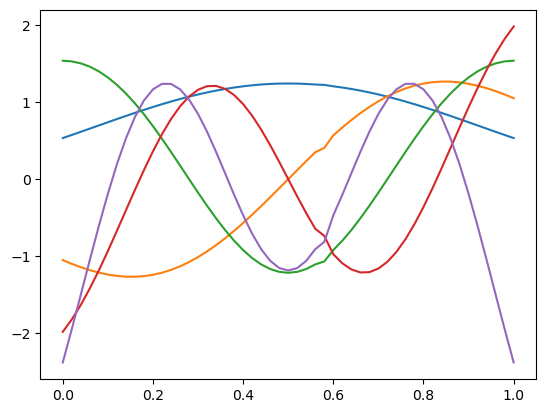

In [12]:
print(f"eigenval_position = {eigval_pos}")
x = np.linspace(0, 1, num=n_sensors_x)
fig, ax = plt.subplots()
ax.plot(x, eigfun_pos[:, 0])
plt.plot(x, eigfun_pos[:, 1])
plt.plot(x, eigfun_pos[:, 2])
plt.plot(x, eigfun_pos[:, 3])
plt.plot(x, eigfun_pos[:, 4])

Initialization of the main variables

In [13]:
n_sensors_t = 2 * n_sensors_x - 1 # number of sensors for the time variable
initial_position = np.zeros((n_samples_functions, n_sensors_x))
initial_velocity = np.zeros((n_samples_functions, n_sensors_x))
repetition_initial_position = np.zeros(
    (n_samples_functions, n_sensors_t, n_sensors_x)
)
repetition_initial_velocity = np.zeros(
    (n_samples_functions, n_sensors_t, n_sensors_x)
)
control = np.zeros((n_samples_functions, n_sensors_t))

Sampling the initial position and velocity, and computation of the exact control, which is given by
$$
	u(t)=\left\{\begin{array}{ll}
		\frac{1}{2}y^0\left(1-t\right) + \frac{1}{2}\int_{1-t}^{1}y^1(s)\, ds  & 0\leq t\leq 1 \\
		& \\
		-\frac{1}{2}y^0\left(t-1\right) + \frac{1}{2}\int_{t-1}^{1}y^1(s)\, ds & 1\leq t\leq 2.
	\end{array}		
	\right.
$$

In [ ]:
rng = np.random.default_rng(seed)
x = np.linspace(0, 1, n_sensors_x)
for k in range(n_samples_functions):
    normal_gaussian_pos = rng.standard_normal(length_KL_expansion_pos) # sampling a standard Gaussian variable
    KL_matrix_pos = np.sqrt(eigval_pos) * eigfun_pos * normal_gaussian_pos # different terms in (1) above
    initial_position[k, :] = np.sum(KL_matrix_pos, axis=1)
    repetition_initial_position[k, :, :] = np.tile(
        initial_position[k, :], (n_sensors_t, 1)
    )
    normal_gaussian_vel = rng.standard_normal(length_KL_expansion_vel)
    KL_matrix_vel = np.sqrt(eigval_vel) * eigfun_vel * normal_gaussian_vel
    initial_velocity[k, :] = np.sum(KL_matrix_vel, axis=1)
    repetition_initial_velocity[k, :, :] = np.tile(
        initial_velocity[k, :], (n_sensors_t, 1)
    )
    integral_d = np.zeros(n_sensors_x)
    for j in range(n_sensors_x):
        z = initial_velocity[k, :]
        integral_d[j] = np.trapz(z[j:], x[j:]) # trapezoidal rule for integration
    y1 = 0.5 * initial_position[k, ::-1] + 0.5 * integral_d[::-1]
    y2 = -0.5 * initial_position[k, 1:] + 0.5 * integral_d[1:]
    control[k, :] = np.hstack((y1, y2))
y = control.reshape(n_samples_functions * n_sensors_t, 1) # vector of labels for training
np.save('y_train_wave', y)
# to generate the vector of labels for test run again the code with a different seed

Finally, we generate the matrix of features (which store the initial positions and velocities)

In [ ]:

repetition_initial_position = np.reshape(
    repetition_initial_position, (n_samples_functions * n_sensors_t, n_sensors_x)
)  # we repeat the datum y^0 in all discrete times
repetition_initial_velocity = np.reshape(
    repetition_initial_velocity, (n_samples_functions * n_sensors_t, n_sensors_x)
)  # we repeat the datum y^1 in all discrete times
initial_data = np.concatenate(
    (repetition_initial_position, repetition_initial_velocity), axis=1
)  # concatenation of position and velocity
t = np.linspace(0, 2, n_sensors_t)
t = np.vstack([t] * n_samples_functions)
t = np.reshape(t, (n_sensors_t * n_samples_functions, 1))
X = np.concatenate((initial_data, t), axis=1)  # matrix of features
np.save('X_train_wave', X)
# to generate the vector of features for test run again the code with a different seed